In [8]:
%%writefile requirements.txt
numpy
matplotlib
cvxpy

Overwriting requirements.txt


In [9]:
!pip3 install -r requirements.txt

  Using cached matplotlib-3.11.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached cvxpy-1.9.2-cp313-cp313-macosx_10_13_universal2.whl.metadata (9.7 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-macosx_10_13_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached packaging-26.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached pillow-12.3.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached osqp-1.1.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.2 kB)
  Using cached clarabel-0.11.1-cp39-abi3-macosx_11_0_arm64.whl.metadata (4.8 kB)
  Using cached scs-3.2.11-cp313-cp313-macosx_11_0_arm64.w

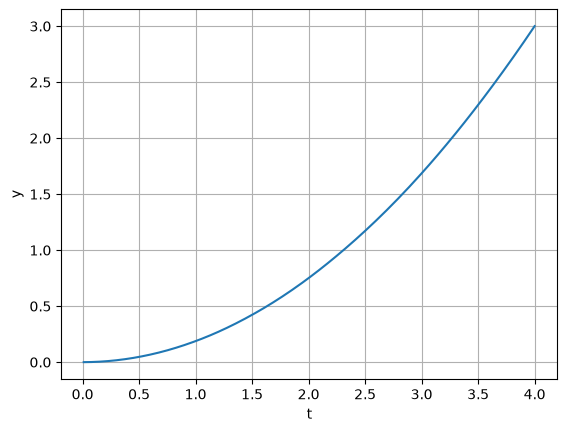

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def lyapunov_function(x, y):
    return 0.5 * (x**2 + y**2)

def system(t, state):
    x, y = state
    return [-x, -2*y]

initial_state = [4.0, 3.0]
t_eval = np.linspace(0, 6, 500)

solution = solve_ivp(
    system,
    t_span=(0, 6),
    y0=initial_state,
    t_eval=t_eval
)

t, y = solution.y
plt.plot(t, y)
plt.xlabel("t")
plt.ylabel("y")
plt.grid()
plt.show()

In [3]:
print(solution)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.202e-02 ...  5.988e+00  6.000e+00]
        y: [[ 4.000e+00  3.952e+00 ...  1.004e-02  9.916e-03]
            [ 3.000e+00  2.929e+00 ...  1.917e-05  1.872e-05]]
      sol: None
 t_events: None
 y_events: None
     nfev: 80
     njev: 0
      nlu: 0


Episode    0 | Reward = -73.78
Episode   50 | Reward = -5.49
Episode  100 | Reward = -1.81
Episode  150 | Reward = -7.18
Episode  200 | Reward = -14.70
Episode  250 | Reward = -3.54
Episode  300 | Reward = -36.13
Episode  350 | Reward = -1.04
Episode  400 | Reward = -1.28
Episode  450 | Reward = -2.55


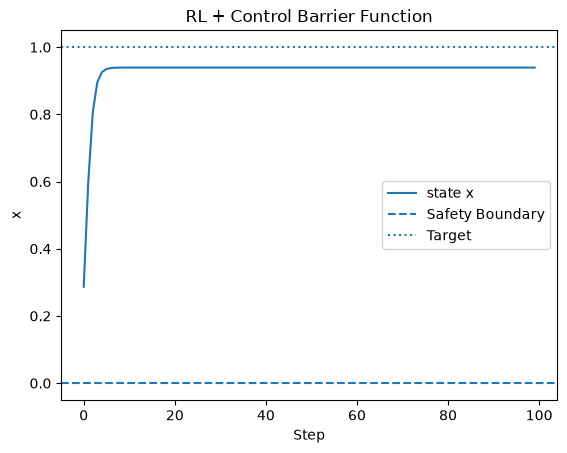

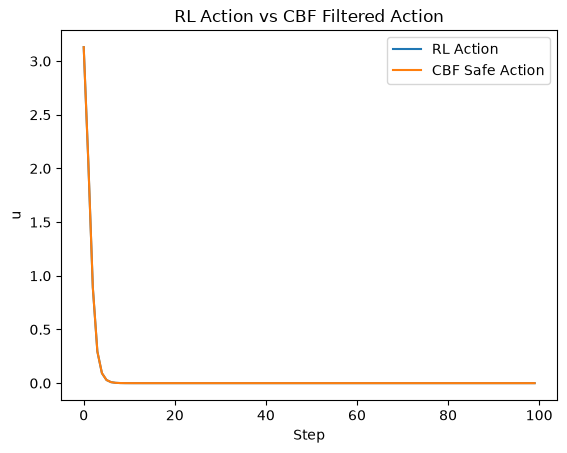

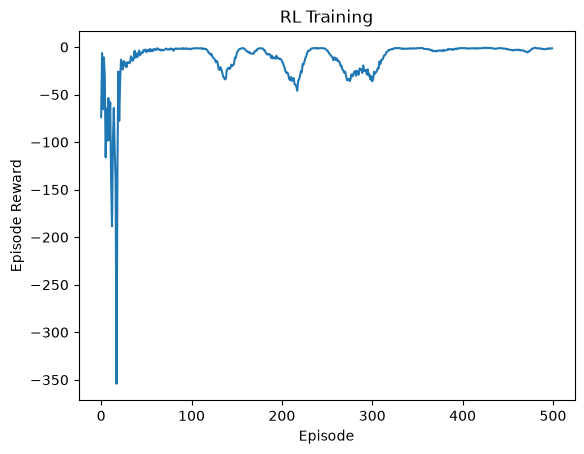

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


# ============================================================
# 1. Simple 1D Environment
#       x_dot = u
#
# Safety constraint:
#       x >= 0
# ============================================================
class SimpleEnv:
    def __init__(self):
        self.dt = 0.1
        self.target = 1.0
        self.max_steps = 100

    def reset(self):
        self.x = np.random.uniform(0.1, 0.5)
        self.step_count = 0
        return np.array([self.x], dtype=np.float32)

    def step(self, u):
        # Dynamics
        self.x = self.x + self.dt * u

        # Reward
        reward = -(self.x - self.target) ** 2 - 0.01 * u ** 2

        self.step_count += 1
        done = self.step_count >= self.max_steps

        return (
            np.array([self.x], dtype=np.float32),
            float(reward),
            done,
        )


# ============================================================
# 2. RL Policy
#
# state x -> Gaussian policy -> u_RL
# ============================================================
class Policy(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1),
        )

        self.log_std = nn.Parameter(torch.tensor([-0.5]))

    def forward(self, state):
        mean = self.net(state)
        std = torch.exp(self.log_std)

        return mean, std

    def sample_action(self, state):
        mean, std = self(state)

        dist = torch.distributions.Normal(mean, std)

        action = dist.sample()
        log_prob = dist.log_prob(action).sum()

        return action, log_prob


# ============================================================
# 3. Control Barrier Function
#
# h(x) = x
#
# CBF condition:
#
#       h_dot + alpha * h >= 0
#
# h_dot = u
#
# therefore:
#
#       u + alpha*x >= 0
#
#       u >= -alpha*x
#
# ============================================================
def cbf_filter(x, u_rl, alpha=1.0):
    cbf_lower_bound = -alpha * x

    # Minimal intervention
    u_safe = max(u_rl, cbf_lower_bound)

    return u_safe


# ============================================================
# 4. RL Training
# ============================================================
env = SimpleEnv()
policy = Policy()

optimizer = optim.Adam(policy.parameters(), lr=3e-3)

gamma = 0.99
num_episodes = 500


reward_history = []


for episode in range(num_episodes):

    state = env.reset()

    log_probs = []
    rewards = []

    episode_reward = 0

    while True:

        # ----------------------------------------------------
        # RL policy
        # ----------------------------------------------------
        state_tensor = torch.tensor(
            state,
            dtype=torch.float32
        )

        action_rl_tensor, log_prob = policy.sample_action(
            state_tensor
        )

        u_rl = action_rl_tensor.item()

        # ----------------------------------------------------
        # CBF Safety Filter
        # ----------------------------------------------------
        x = state[0]

        u_safe = cbf_filter(
            x=x,
            u_rl=u_rl,
            alpha=1.0
        )

        # ----------------------------------------------------
        # Environment receives SAFE action
        # ----------------------------------------------------
        next_state, reward, done = env.step(u_safe)

        log_probs.append(log_prob)
        rewards.append(reward)

        episode_reward += reward

        state = next_state

        if done:
            break

    # ========================================================
    # REINFORCE update
    # ========================================================

    returns = []

    G = 0

    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)

    returns = torch.tensor(
        returns,
        dtype=torch.float32
    )

    # Normalize return
    returns = (
        returns - returns.mean()
    ) / (returns.std() + 1e-8)

    policy_loss = []

    for log_prob, G in zip(log_probs, returns):
        policy_loss.append(-log_prob * G)

    policy_loss = torch.stack(policy_loss).sum()

    optimizer.zero_grad()
    policy_loss.backward()
    optimizer.step()

    reward_history.append(episode_reward)

    if episode % 50 == 0:
        print(
            f"Episode {episode:4d} | "
            f"Reward = {episode_reward:.2f}"
        )


# ============================================================
# 5. Test trained policy
# ============================================================
state = env.reset()

x_history = []
u_rl_history = []
u_safe_history = []


for step in range(100):

    state_tensor = torch.tensor(
        state,
        dtype=torch.float32
    )

    with torch.no_grad():
        mean, _ = policy(state_tensor)

    u_rl = mean.item()

    x = state[0]

    u_safe = cbf_filter(
        x=x,
        u_rl=u_rl,
        alpha=1.0
    )

    x_history.append(x)
    u_rl_history.append(u_rl)
    u_safe_history.append(u_safe)

    state, reward, done = env.step(u_safe)

    if done:
        break


# ============================================================
# 6. Plot
# ============================================================
plt.figure()

plt.plot(x_history, label="state x")
plt.axhline(0, linestyle="--", label="Safety Boundary")
plt.axhline(1, linestyle=":", label="Target")

plt.xlabel("Step")
plt.ylabel("x")
plt.legend()
plt.title("RL + Control Barrier Function")

plt.show()


plt.figure()

plt.plot(u_rl_history, label="RL Action")
plt.plot(u_safe_history, label="CBF Safe Action")

plt.xlabel("Step")
plt.ylabel("u")
plt.legend()
plt.title("RL Action vs CBF Filtered Action")

plt.show()


plt.figure()

plt.plot(reward_history)

plt.xlabel("Episode")
plt.ylabel("Episode Reward")
plt.title("RL Training")

plt.show()

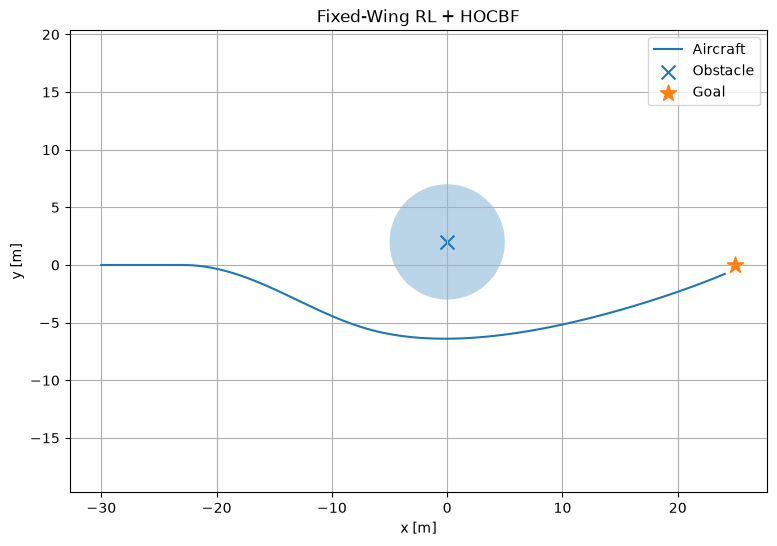

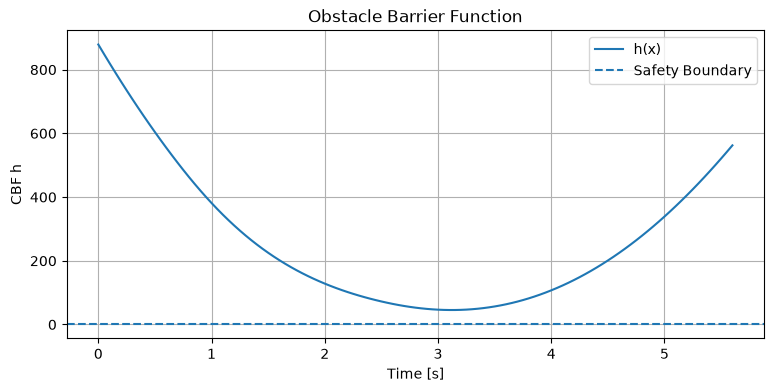

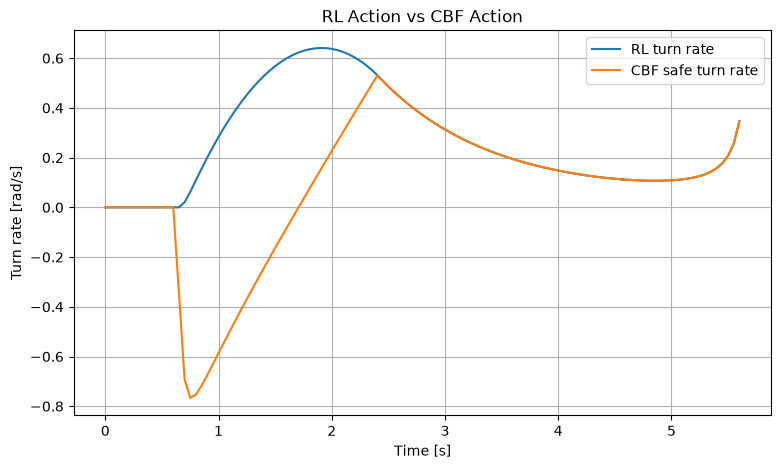

Minimum h: 45.47479789932726
CBF interventions: 36
Final position: [24.53530328 -0.57447985]


In [8]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Configuration
# ============================================================

DT = 0.05

# Goal
GOAL = np.array([25.0, 0.0])

# Obstacle
OBS = np.array([0.0, 2.0])
OBS_RADIUS = 5.0

# Desired airspeed
V_DES = 10.0

# HOCBF gains
GAMMA1 = 1.5
GAMMA2 = 1.5

# QP weight
#
# acceleration을 크게 바꾸는 것보다
# turn rate를 바꾸는 것을 선호
W = np.diag([
    20.0,   # acceleration
    1.0     # turn rate
])

W_INV = np.linalg.inv(W)


# ============================================================
# Utility
# ============================================================

def wrap_angle(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi


# ============================================================
# Fixed-Wing Dynamics
#
# state:
#   [x, y, psi, V]
#
# control:
#   [a, omega]
#
# x_dot   = V cos(psi)
# y_dot   = V sin(psi)
# psi_dot = omega
# V_dot   = a
# ============================================================

def aircraft_step(state, u):

    x, y, psi, V = state

    a = u[0]
    omega = u[1]

    # Euler integration
    x += DT * V * np.cos(psi)
    y += DT * V * np.sin(psi)

    psi += DT * omega
    psi = wrap_angle(psi)

    V += DT * a

    # 단순 simulation safeguard
    V = max(V, 0.1)

    return np.array([
        x,
        y,
        psi,
        V
    ])


# ============================================================
# RL Policy
#
# 현재는 RL 대신 간단한 goal-seeking policy.
#
# 나중에 여기만
#
#   action = SAC(state)
#   action = PPO(state)
#
# 등으로 교체하면 됨.
# ============================================================

def rl_policy(state):

    x, y, psi, V = state

    # Goal heading
    psi_des = np.arctan2(
        GOAL[1] - y,
        GOAL[0] - x
    )

    heading_error = wrap_angle(
        psi_des - psi
    )

    # "RL action" placeholder
    omega_rl = 1.2 * heading_error

    a_rl = 0.8 * (V_DES - V)

    # nominal limits
    omega_rl = np.clip(
        omega_rl,
        -1.0,
        1.0
    )

    a_rl = np.clip(
        a_rl,
        -2.0,
        2.0
    )

    return np.array([
        a_rl,
        omega_rl
    ])


# ============================================================
# HOCBF
#
# h = ||p - p_obs||^2 - R^2
#
# Safety:
#
#       h >= 0
#
# HOCBF:
#
# psi1 = h_dot + gamma1 h
#
# psi2 =
#     h_ddot
#     + (gamma1 + gamma2) h_dot
#     + gamma1 gamma2 h
#
# Require:
#
#       psi2 >= 0
#
# ============================================================

def hocbf_constraint(state):

    x, y, psi, V = state

    position = np.array([
        x,
        y
    ])

    # Relative position
    r = position - OBS

    # Aircraft heading direction
    e = np.array([
        np.cos(psi),
        np.sin(psi)
    ])

    # Perpendicular heading direction
    e_perp = np.array([
        -np.sin(psi),
        np.cos(psi)
    ])

    # --------------------------------------------------------
    # Barrier
    # --------------------------------------------------------

    h = r @ r - OBS_RADIUS**2

    # --------------------------------------------------------
    # First derivative
    #
    # h_dot = 2 r^T v
    # --------------------------------------------------------

    h_dot = 2.0 * V * (r @ e)

    # --------------------------------------------------------
    # Second derivative
    #
    # h_ddot =
    #
    #   2 V^2
    # + 2 r^T e * a
    # + 2 V r^T e_perp * omega
    #
    # --------------------------------------------------------

    drift = 2.0 * V**2

    # Input coefficient
    #
    # L u
    #
    # u = [a, omega]
    #

    L = np.array([
        2.0 * (r @ e),
        2.0 * V * (r @ e_perp)
    ])

    # HOCBF:
    #
    # drift + L u
    # + (g1 + g2) h_dot
    # + g1*g2*h >= 0
    #
    # Therefore:
    #
    # L u >= rhs

    rhs = (
        -drift
        - (GAMMA1 + GAMMA2) * h_dot
        - GAMMA1 * GAMMA2 * h
    )

    return h, h_dot, L, rhs


# ============================================================
# CBF Safety Filter
#
# QP:
#
# min 1/2 (u - u_rl)^T W (u - u_rl)
#
# s.t.
#
#       L u >= rhs
#
#
# 여기서는 constraint가 하나라
# QP solver 없이 closed-form projection 가능.
# ============================================================

def cbf_filter(state, u_rl):

    h, h_dot, L, rhs = hocbf_constraint(
        state
    )

    # Check if RL action is already safe
    cbf_value = L @ u_rl

    if cbf_value >= rhs:

        # No intervention
        return u_rl.copy(), False

    # --------------------------------------------------------
    # QP closed-form solution
    #
    # u_safe =
    #
    # u_rl
    # +
    # lambda W^-1 L^T
    #
    # --------------------------------------------------------

    denominator = (
        L @ W_INV @ L
    )

    if denominator < 1e-10:
        return u_rl.copy(), False

    lam = (
        rhs - L @ u_rl
    ) / denominator

    correction = (
        lam * W_INV @ L
    )

    u_safe = (
        u_rl + correction
    )

    return u_safe, True


# ============================================================
# Simulation
# ============================================================

state = np.array([
    -30.0,   # x
    0.0,     # y
    0.0,     # heading
    10.0     # airspeed
])


trajectory = []

h_history = []

u_rl_history = []
u_safe_history = []

cbf_active_history = []


MAX_STEPS = 1000


for step in range(MAX_STEPS):

    # --------------------------------------------------------
    # 1. RL
    # --------------------------------------------------------

    u_rl = rl_policy(state)

    # --------------------------------------------------------
    # 2. CBF Safety Filter
    # --------------------------------------------------------

    u_safe, cbf_active = cbf_filter(
        state,
        u_rl
    )

    # --------------------------------------------------------
    # 3. Save data
    # --------------------------------------------------------

    h, _, _, _ = hocbf_constraint(
        state
    )

    trajectory.append(
        state.copy()
    )

    h_history.append(h)

    u_rl_history.append(
        u_rl.copy()
    )

    u_safe_history.append(
        u_safe.copy()
    )

    cbf_active_history.append(
        cbf_active
    )

    # --------------------------------------------------------
    # 4. Environment
    # --------------------------------------------------------

    state = aircraft_step(
        state,
        u_safe
    )

    # Goal reached
    distance_goal = np.linalg.norm(
        state[:2] - GOAL
    )

    if distance_goal < 1.0:
        break


# ============================================================
# Convert to numpy
# ============================================================

trajectory = np.array(
    trajectory
)

h_history = np.array(
    h_history
)

u_rl_history = np.array(
    u_rl_history
)

u_safe_history = np.array(
    u_safe_history
)


# ============================================================
# Plot 1
# Trajectory
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    trajectory[:, 0],
    trajectory[:, 1],
    label="Aircraft"
)

# obstacle
circle = plt.Circle(
    OBS,
    OBS_RADIUS,
    alpha=0.3
)

plt.gca().add_patch(circle)

plt.scatter(
    OBS[0],
    OBS[1],
    marker="x",
    s=100,
    label="Obstacle"
)

plt.scatter(
    GOAL[0],
    GOAL[1],
    marker="*",
    s=150,
    label="Goal"
)

plt.axis("equal")

plt.xlabel("x [m]")
plt.ylabel("y [m]")

plt.title(
    "Fixed-Wing RL + HOCBF"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# Plot 2
# Barrier Function
# ============================================================

time = (
    np.arange(len(h_history)) * DT
)

plt.figure(figsize=(9, 4))

plt.plot(
    time,
    h_history,
    label="h(x)"
)

plt.axhline(
    0,
    linestyle="--",
    label="Safety Boundary"
)

plt.xlabel("Time [s]")
plt.ylabel("CBF h")

plt.title(
    "Obstacle Barrier Function"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# Plot 3
# RL vs Safe Action
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    time,
    u_rl_history[:, 1],
    label="RL turn rate"
)

plt.plot(
    time,
    u_safe_history[:, 1],
    label="CBF safe turn rate"
)

plt.xlabel("Time [s]")
plt.ylabel("Turn rate [rad/s]")

plt.title(
    "RL Action vs CBF Action"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# Summary
# ============================================================

print(
    "Minimum h:",
    np.min(h_history)
)

print(
    "CBF interventions:",
    np.sum(cbf_active_history)
)

print(
    "Final position:",
    state[:2]
)

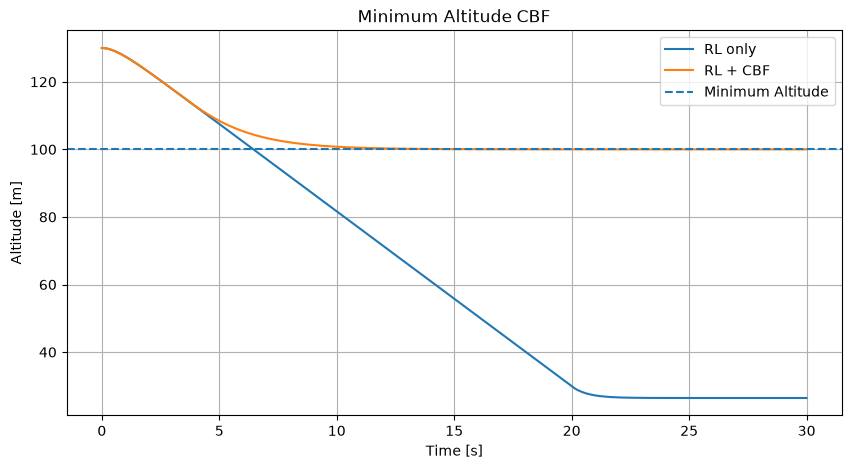

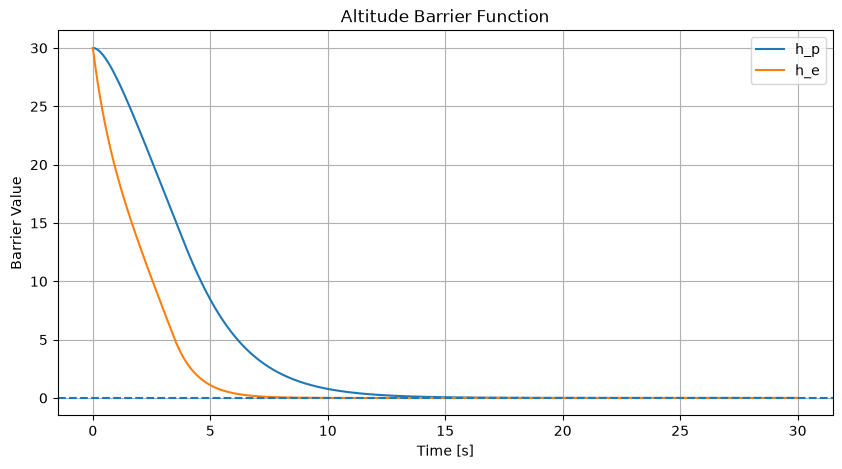

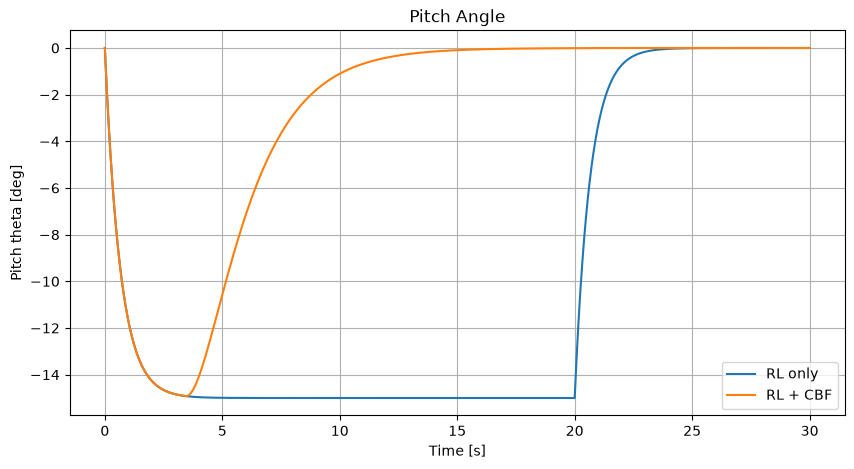

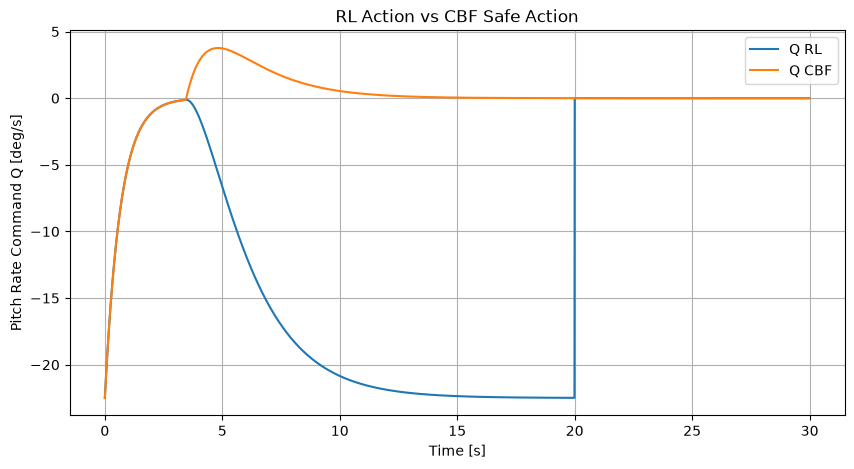

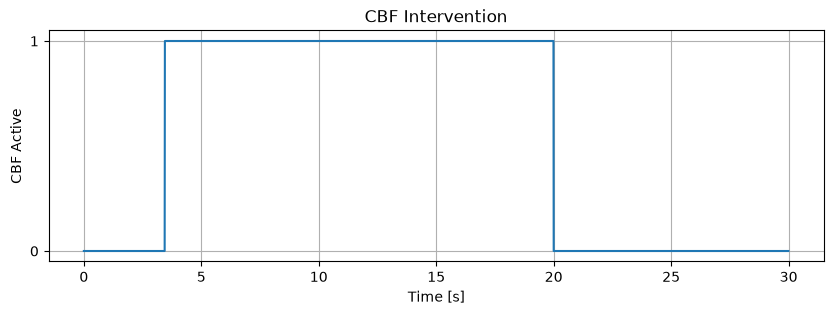

Minimum altitude constraint: 100.0 m
RL only minimum altitude: 26.413303144409294 m
RL + CBF minimum altitude: 100.00358601059222 m
Minimum h_p: 0.003586010592215416
Minimum h_e: 1.3501015650573683e-05
CBF intervention count: 1655


In [10]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Configuration
# ============================================================

G = 9.81

DT = 0.01
T_END = 30.0

# Minimum allowed altitude [m]
H_MIN = 100.0

# NED:
# altitude H = -d
# H >= H_MIN  <=>  d <= -H_MIN
D_MAX = -H_MIN

# Extended CBF parameters
GAMMA_P = 0.5
GAMMA_E = 1.0

# Desired airspeed
V_DES = 20.0

# QP weights for
# [A_T, Q]
#
# Larger A_T weight:
# prefer changing pitch-rate Q rather than acceleration.
W = np.diag([
    10.0,
    1.0,
])

W_INV = np.linalg.inv(W)


# ============================================================
# Fixed-Wing 3D Dubins Model
#
# State:
# x = [n, e, d, phi, theta, psi, V]
#
# Input:
# u = [A_T, P, Q]
#
# Based on:
#
# n_dot = V cos(psi) cos(theta)
# e_dot = V sin(psi) cos(theta)
# d_dot = -V sin(theta)
#
# phi_dot =
#     P
#     + sin(phi) tan(theta) Q
#     + cos(phi) tan(theta) R
#
# theta_dot =
#     cos(phi) Q
#     - sin(phi) R
#
# psi_dot =
#     sin(phi)/cos(theta) Q
#     + cos(phi)/cos(theta) R
#
# V_dot = A_T
#
# R = g/V sin(phi) cos(theta)
# ============================================================

def fixed_wing_dynamics(state, control):

    n, e, d, phi, theta, psi, V = state

    A_T, P, Q = control

    V_safe = max(V, 1e-3)

    # Aircraft turning rate
    R = (
        G / V_safe
        * np.sin(phi)
        * np.cos(theta)
    )

    cos_theta = np.cos(theta)

    # Numerical singularity protection
    if abs(cos_theta) < 1e-4:
        cos_theta = np.sign(cos_theta) * 1e-4

    n_dot = (
        V * np.cos(psi) * np.cos(theta)
    )

    e_dot = (
        V * np.sin(psi) * np.cos(theta)
    )

    d_dot = (
        -V * np.sin(theta)
    )

    phi_dot = (
        P
        + np.sin(phi) * np.tan(theta) * Q
        + np.cos(phi) * np.tan(theta) * R
    )

    theta_dot = (
        np.cos(phi) * Q
        - np.sin(phi) * R
    )

    psi_dot = (
        np.sin(phi) / cos_theta * Q
        + np.cos(phi) / cos_theta * R
    )

    V_dot = A_T

    return np.array([
        n_dot,
        e_dot,
        d_dot,
        phi_dot,
        theta_dot,
        psi_dot,
        V_dot
    ])


# ============================================================
# RK4 Integration
# ============================================================

def rk4_step(state, control):

    k1 = fixed_wing_dynamics(
        state,
        control
    )

    k2 = fixed_wing_dynamics(
        state + 0.5 * DT * k1,
        control
    )

    k3 = fixed_wing_dynamics(
        state + 0.5 * DT * k2,
        control
    )

    k4 = fixed_wing_dynamics(
        state + DT * k3,
        control
    )

    next_state = (
        state
        + DT / 6.0
        * (
            k1
            + 2 * k2
            + 2 * k3
            + k4
        )
    )

    return next_state


# ============================================================
# RL Policy Placeholder
#
# 실제 RL 대신 일부러 계속 하강하려는 controller.
#
# 나중에 여기만:
#
# u_rl = SAC(state)
#
# 또는
#
# u_rl = PPO(state)
#
# 로 변경하면 됨.
# ============================================================

def rl_policy(state, t):

    n, e, d, phi, theta, psi, V = state

    # --------------------------------------------------------
    # Intentionally unsafe policy
    #
    # First 20 sec:
    #   pitch down -15 deg
    #
    # -> aircraft tries to go below minimum altitude
    # --------------------------------------------------------

    if t < 20.0:
        theta_des = np.deg2rad(-15.0)
    else:
        theta_des = np.deg2rad(0.0)

    # Pitch controller
    Q_rl = (
        1.5
        * (theta_des - theta)
    )

    # Airspeed controller
    A_rl = (
        0.8
        * (V_DES - V)
    )

    # Roll stabilization
    P_rl = (
        -2.0 * phi
    )

    # Reasonable pseudo-control limits
    A_rl = np.clip(
        A_rl,
        -3.0,
        3.0
    )

    P_rl = np.clip(
        P_rl,
        np.deg2rad(-30),
        np.deg2rad(30)
    )

    Q_rl = np.clip(
        Q_rl,
        np.deg2rad(-30),
        np.deg2rad(30)
    )

    return np.array([
        A_rl,
        P_rl,
        Q_rl
    ])


# ============================================================
# Minimum Altitude Extended CBF
#
# NED:
#
# altitude H = -d
#
# Safety:
#
# H >= H_min
#
# Therefore:
#
# h_p = H - H_min
#
#     = -d - H_min
#
#     = D_MAX - d
#
#
# h_p >= 0  -> safe
#
#
# d_dot = -V sin(theta)
#
# Therefore:
#
# h_p_dot = V sin(theta)
#
#
# Extended CBF:
#
# h_e =
#     h_p
#     + (1 / gamma_p) h_p_dot
#
#
# CBF condition:
#
# h_e_dot + gamma_e h_e >= 0
# ============================================================

def altitude_cbf(state, u_rl):

    n, e, d, phi, theta, psi, V = state

    A_rl, P_rl, Q_rl = u_rl

    # ========================================================
    # 1. Position Barrier
    # ========================================================

    h_p = (
        D_MAX - d
    )

    # h_p_dot
    h_p_dot = (
        V * np.sin(theta)
    )

    # ========================================================
    # 2. Extended CBF
    # ========================================================

    h_e = (
        h_p
        + h_p_dot / GAMMA_P
    )

    # ========================================================
    # 3. Aircraft turning rate
    # ========================================================

    V_safe = max(
        V,
        1e-3
    )

    R = (
        G / V_safe
        * np.sin(phi)
        * np.cos(theta)
    )

    # ========================================================
    # 4. h_e_dot
    #
    # h_e_dot =
    #
    # V sin(theta)
    #
    # + 1/gamma_p [
    #
    #     A_T sin(theta)
    #
    #     + V cos(theta)
    #       (
    #           cos(phi) Q
    #           - sin(phi) R
    #       )
    #
    # ]
    #
    #
    # = drift + L u
    #
    #
    # u = [A_T, Q]
    # ========================================================

    drift = (
        V * np.sin(theta)
        -
        (
            V
            * np.cos(theta)
            * np.sin(phi)
            * R
        )
        / GAMMA_P
    )

    # Control coefficient
    #
    # L @ [A_T, Q]

    L = np.array([

        np.sin(theta)
        / GAMMA_P,

        (
            V
            * np.cos(theta)
            * np.cos(phi)
        )
        / GAMMA_P

    ])

    # ========================================================
    # CBF condition:
    #
    # drift
    # + L u
    # + gamma_e h_e
    # >= 0
    #
    #
    # therefore
    #
    # L u >= rhs
    # ========================================================

    rhs = (
        -GAMMA_E * h_e
        - drift
    )

    u_reduced_rl = np.array([
        A_rl,
        Q_rl
    ])

    current_value = (
        L @ u_reduced_rl
    )

    # ========================================================
    # RL action already satisfies CBF
    # ========================================================

    if current_value >= rhs:

        return (
            u_rl.copy(),
            False,
            h_p,
            h_e
        )

    # ========================================================
    # QP
    #
    # min
    #
    # 1/2 (u-u_rl)^T W (u-u_rl)
    #
    # subject to
    #
    # L u >= rhs
    #
    #
    # Since only one linear constraint exists,
    # closed-form projection can be used.
    # ========================================================

    denominator = (
        L
        @ W_INV
        @ L
    )

    if denominator < 1e-12:

        return (
            u_rl.copy(),
            False,
            h_p,
            h_e
        )

    lam = (
        rhs - current_value
    ) / denominator

    correction = (
        lam
        * W_INV
        @ L
    )

    u_safe_reduced = (
        u_reduced_rl
        + correction
    )

    A_safe = (
        u_safe_reduced[0]
    )

    Q_safe = (
        u_safe_reduced[1]
    )

    # P is untouched by this altitude CBF
    u_safe = np.array([
        A_safe,
        P_rl,
        Q_safe
    ])

    return (
        u_safe,
        True,
        h_p,
        h_e
    )


# ============================================================
# Simulation
# ============================================================

def simulate(use_cbf=True):

    # --------------------------------------------------------
    # Initial state
    #
    # altitude = 130 m
    #
    # Since NED:
    # d = -130
    # --------------------------------------------------------

    state = np.array([
        0.0,        # n
        0.0,        # e
        -130.0,     # d
        0.0,        # phi
        0.0,        # theta
        0.0,        # psi
        20.0        # V
    ])

    time_history = []
    state_history = []

    u_rl_history = []
    u_safe_history = []

    h_p_history = []
    h_e_history = []

    cbf_active_history = []

    steps = int(
        T_END / DT
    )

    for i in range(steps):

        t = i * DT

        # ====================================================
        # RL controller
        # ====================================================

        u_rl = rl_policy(
            state,
            t
        )

        # ====================================================
        # CBF filter
        # ====================================================

        if use_cbf:

            (
                u_safe,
                active,
                h_p,
                h_e
            ) = altitude_cbf(
                state,
                u_rl
            )

        else:

            u_safe = (
                u_rl.copy()
            )

            active = False

            n, e, d, phi, theta, psi, V = state

            h_p = (
                D_MAX - d
            )

            h_e = (
                h_p
                +
                V
                * np.sin(theta)
                / GAMMA_P
            )

        # ====================================================
        # Log
        # ====================================================

        time_history.append(t)

        state_history.append(
            state.copy()
        )

        u_rl_history.append(
            u_rl.copy()
        )

        u_safe_history.append(
            u_safe.copy()
        )

        h_p_history.append(
            h_p
        )

        h_e_history.append(
            h_e
        )

        cbf_active_history.append(
            active
        )

        # ====================================================
        # Aircraft dynamics
        # ====================================================

        state = rk4_step(
            state,
            u_safe
        )

    return {

        "time":
            np.array(time_history),

        "state":
            np.array(state_history),

        "u_rl":
            np.array(u_rl_history),

        "u_safe":
            np.array(u_safe_history),

        "h_p":
            np.array(h_p_history),

        "h_e":
            np.array(h_e_history),

        "active":
            np.array(cbf_active_history)
    }


# ============================================================
# Run simulations
# ============================================================

without_cbf = simulate(
    use_cbf=False
)

with_cbf = simulate(
    use_cbf=True
)


# ============================================================
# Convert NED d -> altitude
# ============================================================

altitude_without = (
    -without_cbf["state"][:, 2]
)

altitude_with = (
    -with_cbf["state"][:, 2]
)


# ============================================================
# Plot 1
# Altitude
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    without_cbf["time"],
    altitude_without,
    label="RL only"
)

plt.plot(
    with_cbf["time"],
    altitude_with,
    label="RL + CBF"
)

plt.axhline(
    H_MIN,
    linestyle="--",
    label="Minimum Altitude"
)

plt.xlabel(
    "Time [s]"
)

plt.ylabel(
    "Altitude [m]"
)

plt.title(
    "Minimum Altitude CBF"
)

plt.legend()

plt.grid()

plt.show()


# ============================================================
# Plot 2
# Position Barrier
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    with_cbf["time"],
    with_cbf["h_p"],
    label="h_p"
)

plt.plot(
    with_cbf["time"],
    with_cbf["h_e"],
    label="h_e"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Time [s]"
)

plt.ylabel(
    "Barrier Value"
)

plt.title(
    "Altitude Barrier Function"
)

plt.legend()

plt.grid()

plt.show()


# ============================================================
# Plot 3
# Pitch angle
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    without_cbf["time"],
    np.rad2deg(
        without_cbf["state"][:, 4]
    ),
    label="RL only"
)

plt.plot(
    with_cbf["time"],
    np.rad2deg(
        with_cbf["state"][:, 4]
    ),
    label="RL + CBF"
)

plt.xlabel(
    "Time [s]"
)

plt.ylabel(
    "Pitch theta [deg]"
)

plt.title(
    "Pitch Angle"
)

plt.legend()

plt.grid()

plt.show()


# ============================================================
# Plot 4
# RL Q vs CBF Q
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    with_cbf["time"],
    np.rad2deg(
        with_cbf["u_rl"][:, 2]
    ),
    label="Q RL"
)

plt.plot(
    with_cbf["time"],
    np.rad2deg(
        with_cbf["u_safe"][:, 2]
    ),
    label="Q CBF"
)

plt.xlabel(
    "Time [s]"
)

plt.ylabel(
    "Pitch Rate Command Q [deg/s]"
)

plt.title(
    "RL Action vs CBF Safe Action"
)

plt.legend()

plt.grid()

plt.show()


# ============================================================
# Plot 5
# CBF intervention
# ============================================================

plt.figure(
    figsize=(10, 3)
)

plt.plot(
    with_cbf["time"],
    with_cbf["active"].astype(int)
)

plt.xlabel(
    "Time [s]"
)

plt.ylabel(
    "CBF Active"
)

plt.yticks(
    [0, 1]
)

plt.title(
    "CBF Intervention"
)

plt.grid()

plt.show()


# ============================================================
# Results
# ============================================================

print(
    "=================================="
)

print(
    "Minimum altitude constraint:",
    H_MIN,
    "m"
)

print(
    "RL only minimum altitude:",
    np.min(altitude_without),
    "m"
)

print(
    "RL + CBF minimum altitude:",
    np.min(altitude_with),
    "m"
)

print(
    "Minimum h_p:",
    np.min(
        with_cbf["h_p"]
    )
)

print(
    "Minimum h_e:",
    np.min(
        with_cbf["h_e"]
    )
)

print(
    "CBF intervention count:",
    np.sum(
        with_cbf["active"]
    )
)

print(
    "=================================="
)